In [48]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List

# Установим seed для воспроизводимости
np.random.seed(000)


## Базовый класс для всех слоев

Сначала определим базовый класс, от которого будут наследоваться все наши слои:


In [2]:
class Layer:
    """
    Базовый класс для всех слоев нейронной сети
    """
    def __init__(self):
        self.training = True

    def forward(self, x):
        """
        Прямое распространение
        """
        raise NotImplementedError

    def backward(self, grad_output):
        """
        Обратное распространение
        """
        raise NotImplementedError

    def train(self):
        """
        Переключение в режим обучения
        """
        self.training = True

    def eval(self):
        """
        Переключение в режим инференса
        """
        self.training = False

    def __call__(self, x):
        return self.forward(x)


## 1. Функция активации ReLU

### Теория

**ReLU (Rectified Linear Unit)** - одна из самых популярных функций активации в современных нейронных сетях.

**Формула:**
- Forward: `f(x) = max(0, x)`
- Backward: `df/dx = 1 если x > 0, иначе 0`

**Преимущества:**
- Простота вычислений
- Решает проблему затухающих градиентов
- Разреженность активаций

**Недостатки:**
- "Мертвые нейроны" (dying ReLU problem)

### Реализация


In [5]:
class ReLU(Layer):
    def __init__(self):
        super().__init__()
        self.input = None

    def forward(self, x):
        """
        Прямое распространение для ReLU

        Args:
            x: входной тензор формы (batch_size, ...)

        Returns:
            выходной тензор той же формы
        """
        self.input = x

        output = np.maximum(0,x)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для ReLU

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        relu_grad = (self.input > 0).astype(float)

        grad_input = grad_output * relu_grad

        return grad_input


### Тестирование ReLU


In [6]:

relu = ReLU()

# Тестовые данные
x_test = np.array([[-2, -1, 0, 1, 2]], dtype=np.float32)
expected_forward = np.array([[0, 0, 0, 1, 2]], dtype=np.float32)

# Forward pass
output = relu.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")
print(f"Expected: {expected_forward}")

# Проверка forward pass
assert np.allclose(output, expected_forward), "ReLU forward pass не работает корректно!"

# Backward pass
grad_output = np.ones_like(output)
grad_input = relu.backward(grad_output)
expected_backward = np.array([[0, 0, 0, 1, 1]], dtype=np.float32)

print(f"Gradient output: {grad_output}")
print(f"Gradient input: {grad_input}")
print(f"Expected gradient: {expected_backward}")

# Проверка backward pass
assert np.allclose(grad_input, expected_backward), "ReLU backward pass не работает корректно!"

print("✅ ReLU тест пройден успешно!")



Input: [[-2. -1.  0.  1.  2.]]
Output: [[0. 0. 0. 1. 2.]]
Expected: [[0. 0. 0. 1. 2.]]
Gradient output: [[1. 1. 1. 1. 1.]]
Gradient input: [[0. 0. 0. 1. 1.]]
Expected gradient: [[0. 0. 0. 1. 1.]]
✅ ReLU тест пройден успешно!
⚠️ Реализуйте ReLU класс выше, затем раскомментируйте этот код для тестирования


## 2. Функция активации Sigmoid

### Теория

**Sigmoid** - классическая функция активации, которая "сжимает" входные значения в диапазон (0, 1).

**Формула:**
- Forward: `f(x) = 1 / (1 + exp(-x))`
- Backward: `df/dx = f(x) * (1 - f(x))`

**Применение:**
- Бинарная классификация (выходной слой)
- Gating механизмы (LSTM, GRU)

**Проблемы:**
- Затухающие градиенты при глубоких сетях
- Насыщение при больших значениях

### Реализация


In [7]:
class Sigmoid(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Sigmoid

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (0, 1)
        """

        self.output = 1 / (1 + np.exp(-x))

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Sigmoid

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        grad_input = grad_output * self.output * (1 - self.output)

        return grad_input


### Тестирование Sigmoid


In [9]:
sigmoid = Sigmoid()

# Тестовые данные
x_test = np.array([[-10, -1, 0, 1, 10]], dtype=np.float32)

# Forward pass
output = sigmoid.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")

# Проверим, что выходные значения в диапазоне (0, 1)
assert np.all(output > 0) and np.all(output < 1), "Sigmoid должен возвращать значения в диапазоне (0, 1)"

# Проверим симметричность: sigmoid(-x) = 1 - sigmoid(x)
x_sym = np.array([[1]], dtype=np.float32)
out_pos = sigmoid.forward(x_sym)
out_neg = sigmoid.forward(-x_sym)
assert np.allclose(out_neg, 1 - out_pos, atol=1e-6), "Sigmoid должен быть симметричным"

# Backward pass
grad_output = np.ones_like(output)
grad_input = sigmoid.backward(grad_output)
print(f"Gradient input: {grad_input}")

# Проверим, что градиент положительный (sigmoid монотонно возрастает)
assert np.all(grad_input >= 0), "Градиент Sigmoid должен быть неотрицательным"

print("✅ Sigmoid тест пройден успешно!")


Input: [[-10.  -1.   0.   1.  10.]]
Output: [[4.539787e-05 2.689414e-01 5.000000e-01 7.310586e-01 9.999546e-01]]
Gradient input: [[0.19661193 0.19661193 0.19661193 0.19661193 0.19661193]]
✅ Sigmoid тест пройден успешно!


## 3. Функция активации Tanh

### Теория

**Tanh (гиперболический тангенс)** - функция активации, которая "сжимает" входные значения в диапазон (-1, 1).

**Формула:**
- Forward: `f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))`
- Backward: `df/dx = 1 - f(x)²`

**Преимущества над Sigmoid:**
- Выход центрирован вокруг нуля
- Больший диапазон градиентов
- Связь с sigmoid: `tanh(x) = 2*sigmoid(2x) - 1`

### Реализация


In [26]:
class Tanh(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Tanh

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (-1, 1)
        """
        x = x.astype(np.float64)
        self.output = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Tanh

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        grad_input = grad_output * (1 - self.output ** 2)

        return grad_input


### Тестирование Tanh


In [27]:
tanh = Tanh()

# Тестовые данные
x_test = np.array([[-10, -1, 0, 1, 10]], dtype=np.float32)

# Forward pass
output = tanh.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")

# Проверим, что выходные значения в диапазоне (-1, 1)
assert np.all(output > -1) and np.all(output < 1), "Tanh должен возвращать значения в диапазоне (-1, 1)"

# Проверим антисимметричность: tanh(-x) = -tanh(x)
x_antisym = np.array([[2]], dtype=np.float32)
out_pos = tanh.forward(x_antisym)
out_neg = tanh.forward(-x_antisym)
assert np.allclose(out_neg, -out_pos, atol=1e-6), "Tanh должен быть антисимметричным"

# Проверим, что tanh(0) = 0
zero_out = tanh.forward(np.array([[0]], dtype=np.float32))
assert np.allclose(zero_out, 0, atol=1e-6), "tanh(0) должен быть равен 0"

# Backward pass
grad_output = np.ones_like(output)
grad_input = tanh.backward(grad_output)
print(f"Gradient input: {grad_input}")

# Проверим, что градиент положительный (tanh монотонно возрастает)
assert np.all(grad_input >= 0), "Градиент Tanh должен быть неотрицательным"

print("✅ Tanh тест пройден успешно!")


⚠️ Реализуйте Tanh класс выше, затем раскомментируйте этот код для тестирования
Input: [[-10.  -1.   0.   1.  10.]]
Output: [[-1.         -0.76159416  0.          0.76159416  1.        ]]
Gradient input: [[1. 1. 1. 1. 1.]]
✅ Tanh тест пройден успешно!


## 4. Линейный слой (Linear/Dense)

### Теория

**Линейный слой** - основной строительный блок нейронных сетей, выполняющий аффинное преобразование.

**Формула:**
- Forward: `y = x @ W + b`
- где W - матрица весов размера (input_size, output_size)
- b - вектор смещений размера (output_size,)

**Градиенты:**
- `∂L/∂x = grad_output @ W.T`
- `∂L/∂W = x.T @ grad_output`
- `∂L/∂b = sum(grad_output, axis=0)`

**Инициализация весов:**
- Xavier/Glorot: помогает поддерживать дисперсию активаций
- He: оптимизирована для ReLU активаций

### Реализация


In [46]:
class Linear(Layer):
    def __init__(self, input_size, output_size, bias=True):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.use_bias = bias

        self.weight = np.random.uniform(
            low=-np.sqrt(6 / (input_size + output_size)),
            high=np.sqrt(6 / (input_size + output_size)),
            size=(input_size, output_size)
        )

        if self.use_bias:
            self.bias = np.zeros(output_size)
        else:
            self.bias = None

        # Переменные для сохранения входных данных и градиентов
        self.input = None
        self.grad_weight = None
        self.grad_bias = None

    def forward(self, x):
        """
        Прямое распространение для линейного слоя

        Args:
            x: входной тензор формы (batch_size, input_size)

        Returns:
            выходной тензор формы (batch_size, output_size)
        """
        self.input = x

        output = self.input @ self.weight

        if self.use_bias:
            output = self.input @ self.weight + self.bias

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для линейного слоя

        Args:
            grad_output: градиент от следующего слоя формы (batch_size, output_size)

        Returns:
            градиент для предыдущего слоя формы (batch_size, input_size)
        """
        grad_input =  grad_output @ np.transpose(self.weight)

        self.grad_weight = np.transpose(self.input) @ grad_output

        if self.use_bias:
            self.grad_bias = np.sum(grad_output, axis=0)

        return grad_input

    def update_weights(self, learning_rate=0.01):
        """
        Обновление весов с помощью градиентного спуска
        """
        if self.grad_weight is not None:
            self.weight -= learning_rate * self.grad_weight

        if self.use_bias and self.grad_bias is not None:
            self.bias -= learning_rate * self.grad_bias


### Тестирование Linear


In [47]:
linear = Linear(input_size=3, output_size=2, bias=True)

# Проверим форму весов
assert linear.weight.shape == (3, 2), f"Неправильная форма весов: {linear.weight.shape}"
assert linear.bias.shape == (2,), f"Неправильная форма bias: {linear.bias.shape}"

print(f"Веса: \n{linear.weight}")
print(f"Bias: {linear.bias}")

# Тестовые данные
batch_size = 4
x_test = np.random.randn(batch_size, 3).astype(np.float32)

# Forward pass
output = linear.forward(x_test)
expected_shape = (batch_size, 2)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Expected shape: {expected_shape}")

assert output.shape == expected_shape, f"Неправильная форма выхода: {output.shape}"

# Backward pass
grad_output = np.random.randn(*output.shape).astype(np.float32)
grad_input = linear.backward(grad_output)

print(f"Gradient input shape: {grad_input.shape}")
print(f"Gradient weight shape: {linear.grad_weight.shape}")
print(f"Gradient bias shape: {linear.grad_bias.shape}")

# Проверим формы градиентов
assert grad_input.shape == x_test.shape, "Неправильная форма градиента по входу"
assert linear.grad_weight.shape == linear.weight.shape, "Неправильная форма градиента по весам"
assert linear.grad_bias.shape == linear.bias.shape, "Неправильная форма градиента по bias"

print("✅ Linear тест пройден успешно!")


⚠️ Реализуйте Linear класс выше, затем раскомментируйте этот код для тестирования
Веса: 
[[-0.96349772  0.36536757]
 [ 0.37384884 -0.63452002]
 [-0.81298175 -0.40437622]]
Bias: [0. 0.]
Input shape: (4, 3)
Output shape: (4, 2)
Expected shape: (4, 2)
Gradient input shape: (4, 3)
Gradient weight shape: (3, 2)
Gradient bias shape: (2,)
✅ Linear тест пройден успешно!


## 5. Последовательный контейнер (Sequential)

### Теория

**Sequential** - контейнер, который позволяет последовательно применять несколько слоев.

**Принцип работы:**
- Forward: применяет слои по порядку: `output = layer_n(...layer_2(layer_1(input))...)`
- Backward: применяет градиенты в обратном порядке

**Применение:**
- Создание простых feed-forward сетей
- Группировка слоев в блоки
- Упрощение архитектуры кода

### Реализация


In [49]:
class Sequential(Layer):
    def __init__(self, *layers):
        super().__init__()
        self.layers = list(layers)
        self.layer_outputs = []

    def add(self, layer):
        """
        Добавление слоя в последовательность
        """
        self.layers.append(layer)

    def forward(self, x):
        """
        Прямое распространение через все слои

        Args:
            x: входной тензор

        Returns:
            выходной тензор после прохождения всех слоев
        """
        self.layer_outputs = []

        output = x
        for layer in self.layers:
            output = layer.forward(output)
            self.layer_outputs.append(output)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение через все слои в обратном порядке

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

        return grad

    def train(self):
        """
        Переключение всех слоев в режим обучения
        """
        super().train()
        for layer in self.layers:
            layer.train()

    def eval(self):
        """
        Переключение всех слоев в режим инференса
        """
        super().eval()
        for layer in self.layers:
            layer.eval()

    def __len__(self):
        return len(self.layers)

    def __getitem__(self, idx):
        return self.layers[idx]


## 6. Dropout

### Теория

**Dropout** - техника регуляризации, которая случайно "выключает" некоторые нейроны во время обучения.

**Принцип работы:**
- **Обучение**: каждый нейрон сохраняется с вероятностью `(1 - dropout_rate)`
- **Инференс**: все нейроны активны, но выходы масштабируются

**Преимущества:**
- Предотвращает переобучение
- Улучшает обобщающую способность
- Эффект ансамбля моделей

### Реализация


In [123]:
class Dropout(Layer):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.mask = None

    def forward(self, x):
        """
        Прямое распространение для Dropout

        Args:
            x: входной тензор

        Returns:
            выходной тензор с примененным dropout (в режиме обучения)
        """
        if self.training:
            self.mask = (np.random.uniform(size=x.shape) >= (1-self.dropout_rate)).astype(x.dtype)

            output = x * self.mask / (1 - self.dropout_rate)
        else:
            output = x
            self.mask = None

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Dropout

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        if self.training:
            grad_input = grad_output * self.mask / (1 - self.dropout_rate)
        else:
            grad_input = grad_output

        return grad_input


### Тестирование Dropout


In [124]:
dropout = Dropout(dropout_rate=0.5)

# Тестовые данные
x_test = np.ones((100, 10), dtype=np.float32)

# Тест в режиме обучения
dropout.train()
output_train = dropout.forward(x_test)

print(f"Режим обучения:")
print(f"Input mean: {x_test.mean():.3f}")
print(f"Output mean: {output_train.mean():.3f}")
print(f"Proportion of zeros: {(output_train == 0).mean():.3f}")

# Проверим, что часть нейронов "выключена"
zeros_ratio = (output_train == 0).mean()
expected_zeros = 0.5  # dropout_rate
assert abs(zeros_ratio - expected_zeros) < 0.1, f"Неправильная доля нулевых значений: {zeros_ratio}"

# Проверим масштабирование
assert abs(output_train.mean() - x_test.mean()) < 0.1, "Неправильное масштабирование в режиме обучения"

# Тест в режиме инференса
dropout.eval()
output_eval = dropout.forward(x_test)

print(f"\nРежим инференса:")
print(f"Output mean: {output_eval.mean():.3f}")
print(f"Proportion of zeros: {(output_eval == 0).mean():.3f}")

# В режиме инференса все значения должны остаться
assert np.allclose(output_eval, x_test), "В режиме инференса выход должен совпадать с входом"

# Тест backward pass
dropout.train()
output_train = dropout.forward(x_test)
grad_output = np.ones_like(output_train)
grad_input = dropout.backward(grad_output)

print(f"\nGradient test:")
print(f"Grad input shape: {grad_input.shape}")
print(f"Grad input mean: {grad_input.mean():.3f}")

assert grad_input.shape == x_test.shape, "Неправильная форма градиента"

print("✅ Dropout тест пройден успешно!")


Режим обучения:
Input mean: 1.000
Output mean: 0.976
Proportion of zeros: 0.512

Режим инференса:
Output mean: 1.000
Proportion of zeros: 0.000

Gradient test:
Grad input shape: (100, 10)
Grad input mean: 0.982
✅ Dropout тест пройден успешно!


## 7. Batch Normalization

### Теория

**Batch Normalization** - техника нормализации, которая стабилизирует обучение глубоких сетей.

**Принцип работы:**
1. Нормализация: `(x - mean) / sqrt(var + eps)`
2. Масштабирование и сдвиг: `gamma * normalized + beta`

**Преимущества:**
- Ускоряет обучение
- Позволяет использовать большие learning rate
- Уменьшает зависимость от инициализации
- Эффект регуляризации

**Различия между режимами:**
- **Обучение**: используется статистика текущего batch
- **Инференс**: используется накопленная статистика

### Реализация


In [125]:
class BatchNorm(Layer):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)

        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)

        # Переменные для backward pass
        self.batch_mean = None
        self.batch_var = None
        self.normalized = None
        self.input = None
        self.grad_gamma = None
        self.grad_beta = None

    def forward(self, x):
        """
        Прямое распространение для Batch Normalization

        Args:
            x: входной тензор формы (batch_size, num_features)

        Returns:
            нормализованный выходной тензор той же формы
        """
        self.input = x

        if self.training:
            #Вычисление статистики текущего batch
            self.batch_mean = np.mean(x, axis=0)
            self.batch_var = np.var(x, axis=0)

            #Обновление накопленной статистики
            self.running_mean = self.momentum * self.batch_mean + (1 - self.momentum) * self.running_mean

            self.running_var = self.momentum * self.batch_var + (1 - self.momentum) * self.running_var

            mean = self.batch_mean
            var = self.batch_var
        else:
            #Использование накопленной статистики
            mean = self.running_mean
            var = self.running_var

        #Нормализация
        self.normalized = (x - mean) / np.sqrt(var + self.eps)

        #Масштабирование и сдвиг
        output = (x - mean) / np.sqrt(var + self.eps)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Batch Normalization
        """
        #Вычисление градиента по параметрам
        batch_size = grad_output.shape[0]
        self.grad_gamma = np.sum(grad_output * self.normalized, axis=0)
        self.grad_beta = np.sum(grad_output, axis=0)

        #Вычисление градиента по входу
        grad_normalized  = grad_output * self.gamma

        std_inv = 1.0 / np.sqrt(self.batch_var + self.eps)

        grad_input = (
            1.0 / batch_size
            * std_inv
            * (
                batch_size * grad_normalized
                - np.sum(grad_normalized, axis=0)
                - self.normalized * np.sum(grad_normalized * self.normalized, axis=0)
            )
        )

        return grad_input

    def update_weights(self, learning_rate=0.01):
        if self.grad_gamma is not None:
            self.gamma -= learning_rate * self.grad_gamma

        if self.grad_beta is not None:
            self.beta -= learning_rate * self.grad_beta


In [126]:


batch_norm = BatchNorm(num_features=4)

# Проверим инициализацию
assert np.allclose(batch_norm.gamma, 1.0), "Gamma должно инициализироваться единицами"
assert np.allclose(batch_norm.beta, 0.0), "Beta должно инициализироваться нулями"
assert np.allclose(batch_norm.running_mean, 0.0), "Running mean должно инициализироваться нулями"
assert np.allclose(batch_norm.running_var, 1.0), "Running var должно инициализироваться единицами"

print(f"Gamma: {batch_norm.gamma}")
print(f"Beta: {batch_norm.beta}")

# Тестовые данные с известной статистикой
x_test = np.array([
    [1, 2, 3, 4],
    [2, 3, 4, 5],
    [3, 4, 5, 6]
], dtype=np.float32)

print(f"Input: \n{x_test}")
print(f"Input mean per feature: {x_test.mean(axis=0)}")
print(f"Input std per feature: {x_test.std(axis=0)}")

# Forward pass в режиме обучения
batch_norm.train()
output = batch_norm.forward(x_test)

print(f"\nOutput: \n{output}")
print(f"Output mean per feature: {output.mean(axis=0)}")
print(f"Output std per feature: {output.std(axis=0)}")

# Проверим, что выход нормализован (среднее ≈ 0, std ≈ 1)
assert np.allclose(output.mean(axis=0), 0, atol=1e-6), "Среднее должно быть близко к 0"
assert np.allclose(output.std(axis=0), 1, atol=1e-6), "Стандартное отклонение должно быть близко к 1"

# Проверим обновление running статистики
print(f"\nRunning mean: {batch_norm.running_mean}")
print(f"Running var: {batch_norm.running_var}")

# Backward pass
grad_output = np.ones_like(output)
grad_input = batch_norm.backward(grad_output)

print(f"\nGradient input shape: {grad_input.shape}")
print(f"Gradient gamma shape: {batch_norm.grad_gamma.shape}")
print(f"Gradient beta shape: {batch_norm.grad_beta.shape}")

assert grad_input.shape == x_test.shape, "Неправильная форма градиента по входу"
assert batch_norm.grad_gamma.shape == batch_norm.gamma.shape, "Неправильная форма градиента gamma"
assert batch_norm.grad_beta.shape == batch_norm.beta.shape, "Неправильная форма градиента beta"

# Тест режима инференса
batch_norm.eval()
output_eval = batch_norm.forward(x_test)
print(f"\nInference mode output mean: {output_eval.mean(axis=0)}")

print("✅ BatchNorm тест пройден успешно!")


⚠️ Реализуйте BatchNorm класс выше, затем раскомментируйте этот код для тестирования
Gamma: [1. 1. 1. 1.]
Beta: [0. 0. 0. 0.]
Input: 
[[1. 2. 3. 4.]
 [2. 3. 4. 5.]
 [3. 4. 5. 6.]]
Input mean per feature: [2. 3. 4. 5.]
Input std per feature: [0.8164966 0.8164966 0.8164966 0.8164966]

Output: 
[[-1.2247356 -1.2247356 -1.2247356 -1.2247356]
 [ 0.         0.         0.         0.       ]
 [ 1.2247356  1.2247356  1.2247356  1.2247356]]
Output mean per feature: [0. 0. 0. 0.]
Output std per feature: [0.99999243 0.99999243 0.99999243 0.99999243]

Running mean: [0.2        0.30000001 0.40000001 0.5       ]
Running var: [0.96666667 0.96666667 0.96666667 0.96666667]

Gradient input shape: (3, 4)
Gradient gamma shape: (4,)
Gradient beta shape: (4,)

Inference mode output mean: [1.83076198 2.74614297 3.66152397 4.57690497]
✅ BatchNorm тест пройден успешно!


## 8. Adam Оптимизатор

### Теория

**Adam (Adaptive Moment Estimation)** - современный оптимизатор, сочетающий преимущества RMSprop и Momentum.

**Принцип работы:**
1. Вычисление экспоненциального скользящего среднего градиентов (momentum)
2. Вычисление экспоненциального скользящего среднего квадратов градиентов (RMSprop)
3. Коррекция смещения (bias correction)
4. Обновление параметров

**Преимущества:**
- Адаптивные learning rate для каждого параметра
- Хорошо работает на практике
- Требует мало настройки гиперпараметров

### Реализация


In [129]:
class Adam:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # Словари для хранения моментов для каждого слоя
        self.m = {}  # first moment
        self.v = {}  # second moment
        self.t = 0   # time step

    def update(self, layer, layer_id):
        """
        Обновление параметров слоя с помощью Adam

        Args:
            layer: слой с градиентами
            layer_id: уникальный идентификатор слоя
        """
        self.t += 1

        # Обновляем веса, если есть градиенты
        if hasattr(layer, 'grad_weight') and layer.grad_weight is not None:
            # Инициализация моментов для весов
            weight_key = f"{layer_id}_weight"
            if f"{layer_id}_weight" not in self.m:
                self.m[f"{layer_id}_weight"] = np.zeros_like(layer.weight)
                self.v[f"{layer_id}_weight"] = np.zeros_like(layer.weight)

            # Обновление первого момента (momentum)
            self.m[f"{layer_id}_weight"] = self.beta1 * self.m[weight_key] + (1 - self.beta1) * layer.grad_weight

            # Обновление второго момента (RMSprop)
            self.v[f"{layer_id}_weight"] = self.beta2 * self.v[weight_key] + (1 - self.beta2) * (layer.grad_weight ** 2)

            # Коррекция смещения
            m_corrected = self.m[weight_key] / (1 - self.beta1 ** self.t)
            v_corrected =  self.v[weight_key] / (1 - self.beta2 ** self.t)

            # Обновляем веса
            layer.weight = layer.weight - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)

        # Обновление bias
        if hasattr(layer, 'grad_bias') and layer.grad_bias is not None:
            bias_key = f"{layer_id}_bias"
            if f"{layer_id}_bias" not in self.m:
                self.m[f"{layer_id}_bias"] = np.zeros_like(layer.bias)
                self.v[f"{layer_id}_bias"] = np.zeros_like(layer.bias)

            self.m[bias_key] = self.beta1 * self.m[bias_key] + (1 - self.beta1) * layer.grad_bias

            self.v[bias_key] = self.beta2 * self.v[bias_key] + (1 - self.beta2) * (layer.grad_bias ** 2)

            # Коррекция смещения
            m_corrected = self.m[bias_key] / (1 - self.beta1 ** self.t)
            v_corrected = self.v[bias_key] / (1 - self.beta2 ** self.t)

            # Обновляем bias
            layer.bias = layer.bias - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)



    def zero_grad(self, layers):
        """
        Обнуление градиентов
        """
        for layer in layers:
            if hasattr(layer, 'grad_weight'):
                layer.grad_weight = None
            if hasattr(layer, 'grad_bias'):
                layer.grad_bias = None
            if hasattr(layer, 'grad_gamma'):
                layer.grad_gamma = None
            if hasattr(layer, 'grad_beta'):
                layer.grad_beta = None


In [130]:
# Тест Adam
# Создание тестового слоя
layer = Linear(3, 2)
adam = Adam(learning_rate=0.01)

# Создание фиктивных градиентов
layer.grad_weight = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]], dtype=np.float32)
layer.grad_bias = np.array([0.1, 0.2], dtype=np.float32)

# Сохранение начальных весов
initial_weight = layer.weight.copy()
initial_bias = layer.bias.copy()

print(f"Initial weight: \n{initial_weight}")
print(f"Initial bias: {initial_bias}")
print(f"Weight gradient: \n{layer.grad_weight}")
print(f"Bias gradient: {layer.grad_bias}")

# Проверим инициализацию Adam
assert len(adam.m) == 0, "Моменты должны быть пустыми при инициализации"
assert len(adam.v) == 0, "Моменты должны быть пустыми при инициализации"
assert adam.t == 0, "Time step должен быть равен 0"

# Выполним один шаг оптимизации
adam.update(layer, "test_layer")

print(f"\nAfter 1 step:")
print(f"Updated weight: \n{layer.weight}")
print(f"Updated bias: {layer.bias}")
print(f"Time step: {adam.t}")

# Проверим, что веса изменились
assert not np.allclose(layer.weight, initial_weight), "Веса должны измениться после обновления"
assert not np.allclose(layer.bias, initial_bias), "Bias должен измениться после обновления"

# Проверим, что моменты инициализированы
assert "test_layer_weight" in adam.m, "Момент для весов должен быть создан"
assert "test_layer_bias" in adam.m, "Момент для bias должен быть создан"
assert "test_layer_weight" in adam.v, "Момент для весов должен быть создан"
assert "test_layer_bias" in adam.v, "Момент для bias должен быть создан"

# Проверим формы моментов
assert adam.m["test_layer_weight"].shape == layer.weight.shape, "Неправильная форма момента весов"
assert adam.m["test_layer_bias"].shape == layer.bias.shape, "Неправильная форма момента bias"

# Тест zero_grad
adam.zero_grad([layer])
assert layer.grad_weight is None, "Градиенты весов должны быть обнулены"
assert layer.grad_bias is None, "Градиенты bias должны быть обнулены"

print("✅ Adam тест пройден успешно!")


⚠️ Реализуйте Adam класс выше, затем раскомментируйте этот код для тестирования
Initial weight: 
[[ 0.46836134  0.47460377]
 [-1.03030264  0.09169283]
 [ 0.36328743  0.61163264]]
Initial bias: [0. 0.]
Weight gradient: 
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]]
Bias gradient: [0.1 0.2]

After 1 step:
Updated weight: 
[[ 0.45836134  0.46460377]
 [-1.04030264  0.08169283]
 [ 0.35328743  0.60163264]]
Updated bias: [-0.01 -0.01]
Time step: 1
✅ Adam тест пройден успешно!


## 9. Функции потерь

### Теория

**Функции потерь** измеряют разность между предсказаниями модели и истинными значениями.

**Cross-Entropy Loss:**
- Используется для задач классификации
- Формула: `-log(p_correct_class)`
- Штрафует неверные предсказания экспоненциально

**Mean Squared Error (MSE):**
- Используется для задач регрессии
- Формула: `(y_pred - y_true)²`
- Чувствителен к выбросам

### Реализация


In [166]:
class CrossEntropyLoss:
    def __init__(self):
        self.predictions = None
        self.targets = None
        self.softmax_pred = None

    def forward(self, predictions, targets):
        """
        Вычисление Cross-Entropy Loss

        Args:
            predictions: предсказания модели (batch_size, num_classes)
            targets: истинные метки класса (batch_size,)

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        self.targets = targets

        # TODO: Примените softmax к предсказаниям
        self.softmax_pred = softmax(predictions)

        # TODO: Вычислите cross-entropy loss
        batch_size = predictions.shape[0]
        correct_class_probs = self.softmax_pred[np.arange(batch_size), targets]
        loss = -np.mean(np.log(correct_class_probs))

        return loss

    def backward(self):
        """
        Вычисление градиента Cross-Entropy Loss

        Returns:
            градиент по предсказаниям
        """
        # TODO: Вычислите градиент
        batch_size =  self.predictions.shape[0]

        grad= self.softmax_pred.copy()
        grad[np.arange(batch_size), self.targets] -= 1
        grad /= batch_size

        return grad


class MSELoss:
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """
        Вычисление Mean Squared Error

        Args:
            predictions: предсказания модели
            targets: истинные значения

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        self.targets = targets

        # TODO: Вычислите MSE
        loss = np.mean((self.predictions-self.targets) ** 2)

        return loss

    def backward(self):
        """
        Вычисление градиента MSE

        Returns:
            градиент по предсказаниям
        """
        # TODO: Вычислите градиент MSE
        n = self.predictions.size
        grad = 2 * (self.predictions - self.targets) / n

        return grad


def softmax(x):
    """
    Устойчивая реализация softmax
    """
    x = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x)/np.sum(np.exp(x), axis=1, keepdims=True)


def one_hot_encode(labels, num_classes):
    """
    Преобразование меток в one-hot кодировку
    """
    # TODO: Создайте one-hot кодировку
    labels = np.array(labels, dtype=int)

    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot


In [167]:
# Тест функций потерь (запустите после реализации Loss функций)

# Тест CrossEntropyLoss
print("🔥 Тестирование CrossEntropyLoss...")
ce_loss = CrossEntropyLoss()

# Тестовые данные
predictions = np.array([[2.0, 1.0, 0.1], [1.0, 3.0, 0.2]], dtype=np.float32)
targets = np.array([0, 1], dtype=np.int32)

print(f"Predictions: \n{predictions}")
print(f"Targets: {targets}")

# Forward pass
loss_value = ce_loss.forward(predictions, targets)
print(f"CrossEntropy Loss: {loss_value:.4f}")

# Проверим, что loss положительный
assert loss_value > 0, "CrossEntropy loss должен быть положительным"

# Backward pass
grad = ce_loss.backward()
print(f"Gradient shape: {grad.shape}")
print(f"Gradient: \n{grad}")

# Проверим форму градиента
assert grad.shape == predictions.shape, "Неправильная форма градиента CrossEntropy"

# Проверим, что сумма градиентов по классам равна 0 (свойство softmax)
assert np.allclose(grad.sum(axis=1), 0, atol=1e-6), "Сумма градиентов по классам должна быть 0"

print("✅ CrossEntropyLoss тест пройден!")

# Тест MSELoss
print("\n📊 Тестирование MSELoss...")
mse_loss = MSELoss()

# Тестовые данные для регрессии
predictions_reg = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
targets_reg = np.array([[1.5, 2.5], [2.5, 3.5]], dtype=np.float32)

print(f"Predictions: \n{predictions_reg}")
print(f"Targets: \n{targets_reg}")

# Forward pass
mse_value = mse_loss.forward(predictions_reg, targets_reg)
print(f"MSE Loss: {mse_value:.4f}")

# Проверим, что loss положительный
assert mse_value >= 0, "MSE loss должен быть неотрицательным"

# Backward pass
grad_mse = mse_loss.backward()
print(f"MSE Gradient shape: {grad_mse.shape}")
print(f"MSE Gradient: \n{grad_mse}")

# Проверим форму градиента
assert grad_mse.shape == predictions_reg.shape, "Неправильная форма градиента MSE"

print("✅ MSELoss тест пройден!")

# Тест softmax функции
print("\n🎯 Тестирование Softmax...")
x_softmax = np.array([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]], dtype=np.float32)
softmax_output = softmax(x_softmax)

print(f"Input: \n{x_softmax}")
print(f"Softmax output: \n{softmax_output}")

# Проверим, что сумма вероятностей равна 1
assert np.allclose(softmax_output.sum(axis=1), 1.0), "Сумма softmax должна быть равна 1"

# Проверим, что все значения положительные
assert np.all(softmax_output > 0), "Все значения softmax должны быть положительными"
assert np.all(softmax_output < 1), "Все значения softmax должны быть меньше 1"

print("✅ Softmax тест пройден!")

# Тест one-hot encoding
print("\n🏷️ Тестирование One-hot encoding...")
labels = np.array([0, 2, 1, 0])
one_hot = one_hot_encode(labels, num_classes=3)

print(f"Labels: {labels}")
print(f"One-hot: \n{one_hot}")

# Проверим форму
assert one_hot.shape == (4, 3), "Неправильная форма one-hot кодировки"

# Проверим, что каждая строка содержит ровно одну единицу
assert np.all(one_hot.sum(axis=1) == 1), "Каждая строка должна содержать ровно одну единицу"

print("✅ One-hot encoding тест пройден!")

print("\n🎉 Все тесты функций потерь пройдены успешно!")


🔥 Тестирование CrossEntropyLoss...
Predictions: 
[[2.  1.  0.1]
 [1.  3.  0.2]]
Targets: [0 1]
CrossEntropy Loss: 0.2981
Gradient shape: (2, 3)
Gradient: 
[[-0.17049944  0.12121648  0.04928295]
 [ 0.05657142 -0.08199063  0.02541918]]
✅ CrossEntropyLoss тест пройден!

📊 Тестирование MSELoss...
Predictions: 
[[1. 2.]
 [3. 4.]]
Targets: 
[[1.5 2.5]
 [2.5 3.5]]
MSE Loss: 0.2500
MSE Gradient shape: (2, 2)
MSE Gradient: 
[[-0.25 -0.25]
 [ 0.25  0.25]]
✅ MSELoss тест пройден!

🎯 Тестирование Softmax...
Input: 
[[1. 2. 3.]
 [1. 1. 1.]]
Softmax output: 
[[0.09003057 0.24472846 0.66524094]
 [0.33333334 0.33333334 0.33333334]]
✅ Softmax тест пройден!

🏷️ Тестирование One-hot encoding...
Labels: [0 2 1 0]
One-hot: 
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
✅ One-hot encoding тест пройден!

🎉 Все тесты функций потерь пройдены успешно!


## 10. Обновленная архитектура нейронной сети

Теперь создаем нейронную сеть с использованием всех реализованных компонентов с протестируем ее на синтетических данных

In [183]:
class NeuralNetwork:
  def __init__(self):
    self.model = Sequential(
      Linear(2, 16),
      ReLU(),
      Linear(16, 2)
    )
  def forward(self, x):
        return self.model.forward(x)

  def backward(self, grad_output):
        return self.model.backward(grad_output)

  def train(self):
        self.model.train()

  def eval(self):
        self.model.eval()

  def get_trainable_layers(self):
        """
        Получение всех слоев с обучаемыми параметрами
        """
        trainable_layers = []
        for layer in self.model.layers:
            if hasattr(layer, 'update_weights'):
                trainable_layers.append(layer)
        return trainable_layers



In [176]:
n_samples_per_class = 100

# Класс 0: точки около (-2, -2)
X0 = np.random.randn(n_samples_per_class, 2) + np.array([-2, -2])
y0 = np.zeros(n_samples_per_class, dtype=int)

# Класс 1: точки около (2, 2)
X1 = np.random.randn(n_samples_per_class, 2) + np.array([2, 2])
y1 = np.ones(n_samples_per_class, dtype=int)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

# Перемешаем данные
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [185]:
network = NeuralNetwork()

criterion = CrossEntropyLoss()
optimizer = Adam(learning_rate=0.01)

In [186]:
epochs = 20
loss_history = []

network.train()

for epoch in range(epochs):

    logits = network.forward(X)

    loss = criterion.forward(logits, y)
    loss_history.append(loss)

    grad_loss = criterion.backward()
    network.backward(grad_loss)

    for layer_id, layer in enumerate(network.model.layers):
        optimizer.update(layer, layer_id)

    optimizer.zero_grad(network.model.layers)

    print(f"Epoch {epoch + 1}/{epochs}, loss = {loss:.4f}")

Epoch 1/20, loss = 0.6281
Epoch 2/20, loss = 0.5247
Epoch 3/20, loss = 0.4457
Epoch 4/20, loss = 0.3766
Epoch 5/20, loss = 0.3176
Epoch 6/20, loss = 0.2682
Epoch 7/20, loss = 0.2271
Epoch 8/20, loss = 0.1927
Epoch 9/20, loss = 0.1636
Epoch 10/20, loss = 0.1389
Epoch 11/20, loss = 0.1177
Epoch 12/20, loss = 0.0996
Epoch 13/20, loss = 0.0841
Epoch 14/20, loss = 0.0709
Epoch 15/20, loss = 0.0596
Epoch 16/20, loss = 0.0500
Epoch 17/20, loss = 0.0419
Epoch 18/20, loss = 0.0351
Epoch 19/20, loss = 0.0295
Epoch 20/20, loss = 0.0249


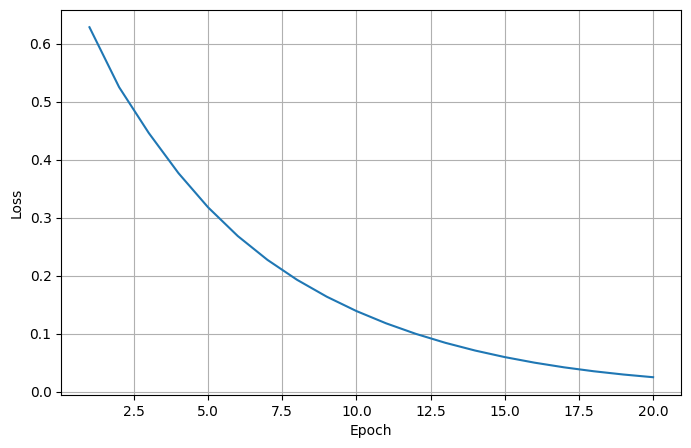

In [193]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [191]:
network.eval()

logits = network.forward(X)
probs = softmax(logits)
preds = np.argmax(probs, axis=1)

accuracy = np.mean(preds == y)

print(f"Accuracy: {accuracy}")

Accuracy: 1.0


##11. Тест на датасете MNIST
Теперь протестируем реализацию нашей нейросети на датасете MNIST

In [195]:
import pandas as pd

In [196]:
df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [197]:
y = df["label"].values
X = df.drop(columns=["label"]).values

In [198]:
X = X.astype(np.float32) / 255.0
y = y.astype(int)

In [199]:
indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
val_idx = indices[train_size:]

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(33600, 784) (33600,)
(8400, 784) (8400,)


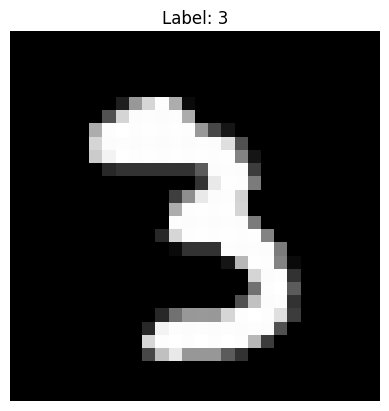

In [200]:
idx = 0

plt.imshow(X_train[idx].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[idx]}")
plt.axis("off")
plt.show()

In [201]:
class DigitNeuralNetwork:
    def __init__(self):
        self.model = Sequential(
            Linear(784, 128),
            ReLU(),
            Linear(128, 10)
        )

    def forward(self, x):
        return self.model.forward(x)

    def backward(self, grad_output):
        return self.model.backward(grad_output)

    def train(self):
        self.model.train()

    def eval(self):
        self.model.eval()

In [202]:
network = DigitNeuralNetwork()

In [204]:
criterion = CrossEntropyLoss()
optimizer = Adam(learning_rate=0.001)

epochs = 20
batch_size = 128

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

network.train()

for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train[permutation]

    epoch_losses = []

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        logits = network.forward(X_batch)

        loss = criterion.forward(logits, y_batch)
        epoch_losses.append(loss)

        grad_loss = criterion.backward()
        network.backward(grad_loss)

        # Update
        for layer_id, layer in enumerate(network.model.layers):
            optimizer.update(layer, layer_id)

        # Zero grad
        optimizer.zero_grad(network.model.layers)

    # Средний train loss за эпоху
    train_loss = np.mean(epoch_losses)
    train_losses.append(train_loss)

    # Оценка на train
    train_logits = network.forward(X_train[:5000])
    train_acc = accuracy_score_custom(train_logits, y_train[:5000])
    train_accuracies.append(train_acc)

    # Оценка на validation
    network.eval()
    val_logits = network.forward(X_val)
    val_loss = criterion.forward(val_logits, y_val)
    val_acc = accuracy_score_custom(val_logits, y_val)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    network.train()

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

Epoch 1/20 | train_loss=0.4152 | val_loss=0.2243 | train_acc=0.9388 | val_acc=0.9323
Epoch 2/20 | train_loss=0.1824 | val_loss=0.1560 | train_acc=0.9616 | val_acc=0.9531
Epoch 3/20 | train_loss=0.1307 | val_loss=0.1376 | train_acc=0.9662 | val_acc=0.9588
Epoch 4/20 | train_loss=0.1030 | val_loss=0.1263 | train_acc=0.9724 | val_acc=0.9598
Epoch 5/20 | train_loss=0.0850 | val_loss=0.1128 | train_acc=0.9782 | val_acc=0.9648
Epoch 6/20 | train_loss=0.0703 | val_loss=0.1122 | train_acc=0.9800 | val_acc=0.9642
Epoch 7/20 | train_loss=0.0592 | val_loss=0.1002 | train_acc=0.9860 | val_acc=0.9674
Epoch 8/20 | train_loss=0.0495 | val_loss=0.1040 | train_acc=0.9880 | val_acc=0.9664
Epoch 9/20 | train_loss=0.0420 | val_loss=0.0966 | train_acc=0.9920 | val_acc=0.9702
Epoch 10/20 | train_loss=0.0366 | val_loss=0.0932 | train_acc=0.9914 | val_acc=0.9711
Epoch 11/20 | train_loss=0.0313 | val_loss=0.0919 | train_acc=0.9954 | val_acc=0.9730
Epoch 12/20 | train_loss=0.0255 | val_loss=0.0901 | train_acc=0

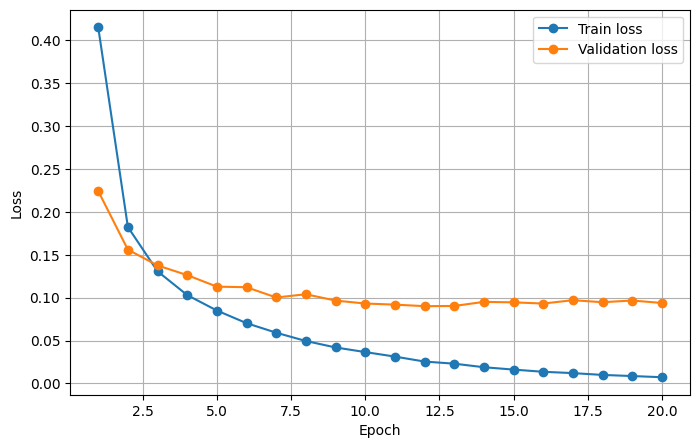

In [205]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train loss")
plt.plot(range(1, epochs + 1), val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [207]:
test_df = pd.read_csv("test.csv")

print(test_df.shape)
test_df.head()

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [209]:
X_test = test_df.values.astype(np.float32) / 255.0

X_test.shape

(28000, 784)

In [210]:
network.eval()

test_logits = network.forward(X_test)
test_probs = softmax(test_logits)
test_preds = np.argmax(test_probs, axis=1)

print(test_preds[:20])

[2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]


In [211]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_preds) + 1),
    "Label": test_preds
})

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [212]:
submission.to_csv("submission.csv", index=False)

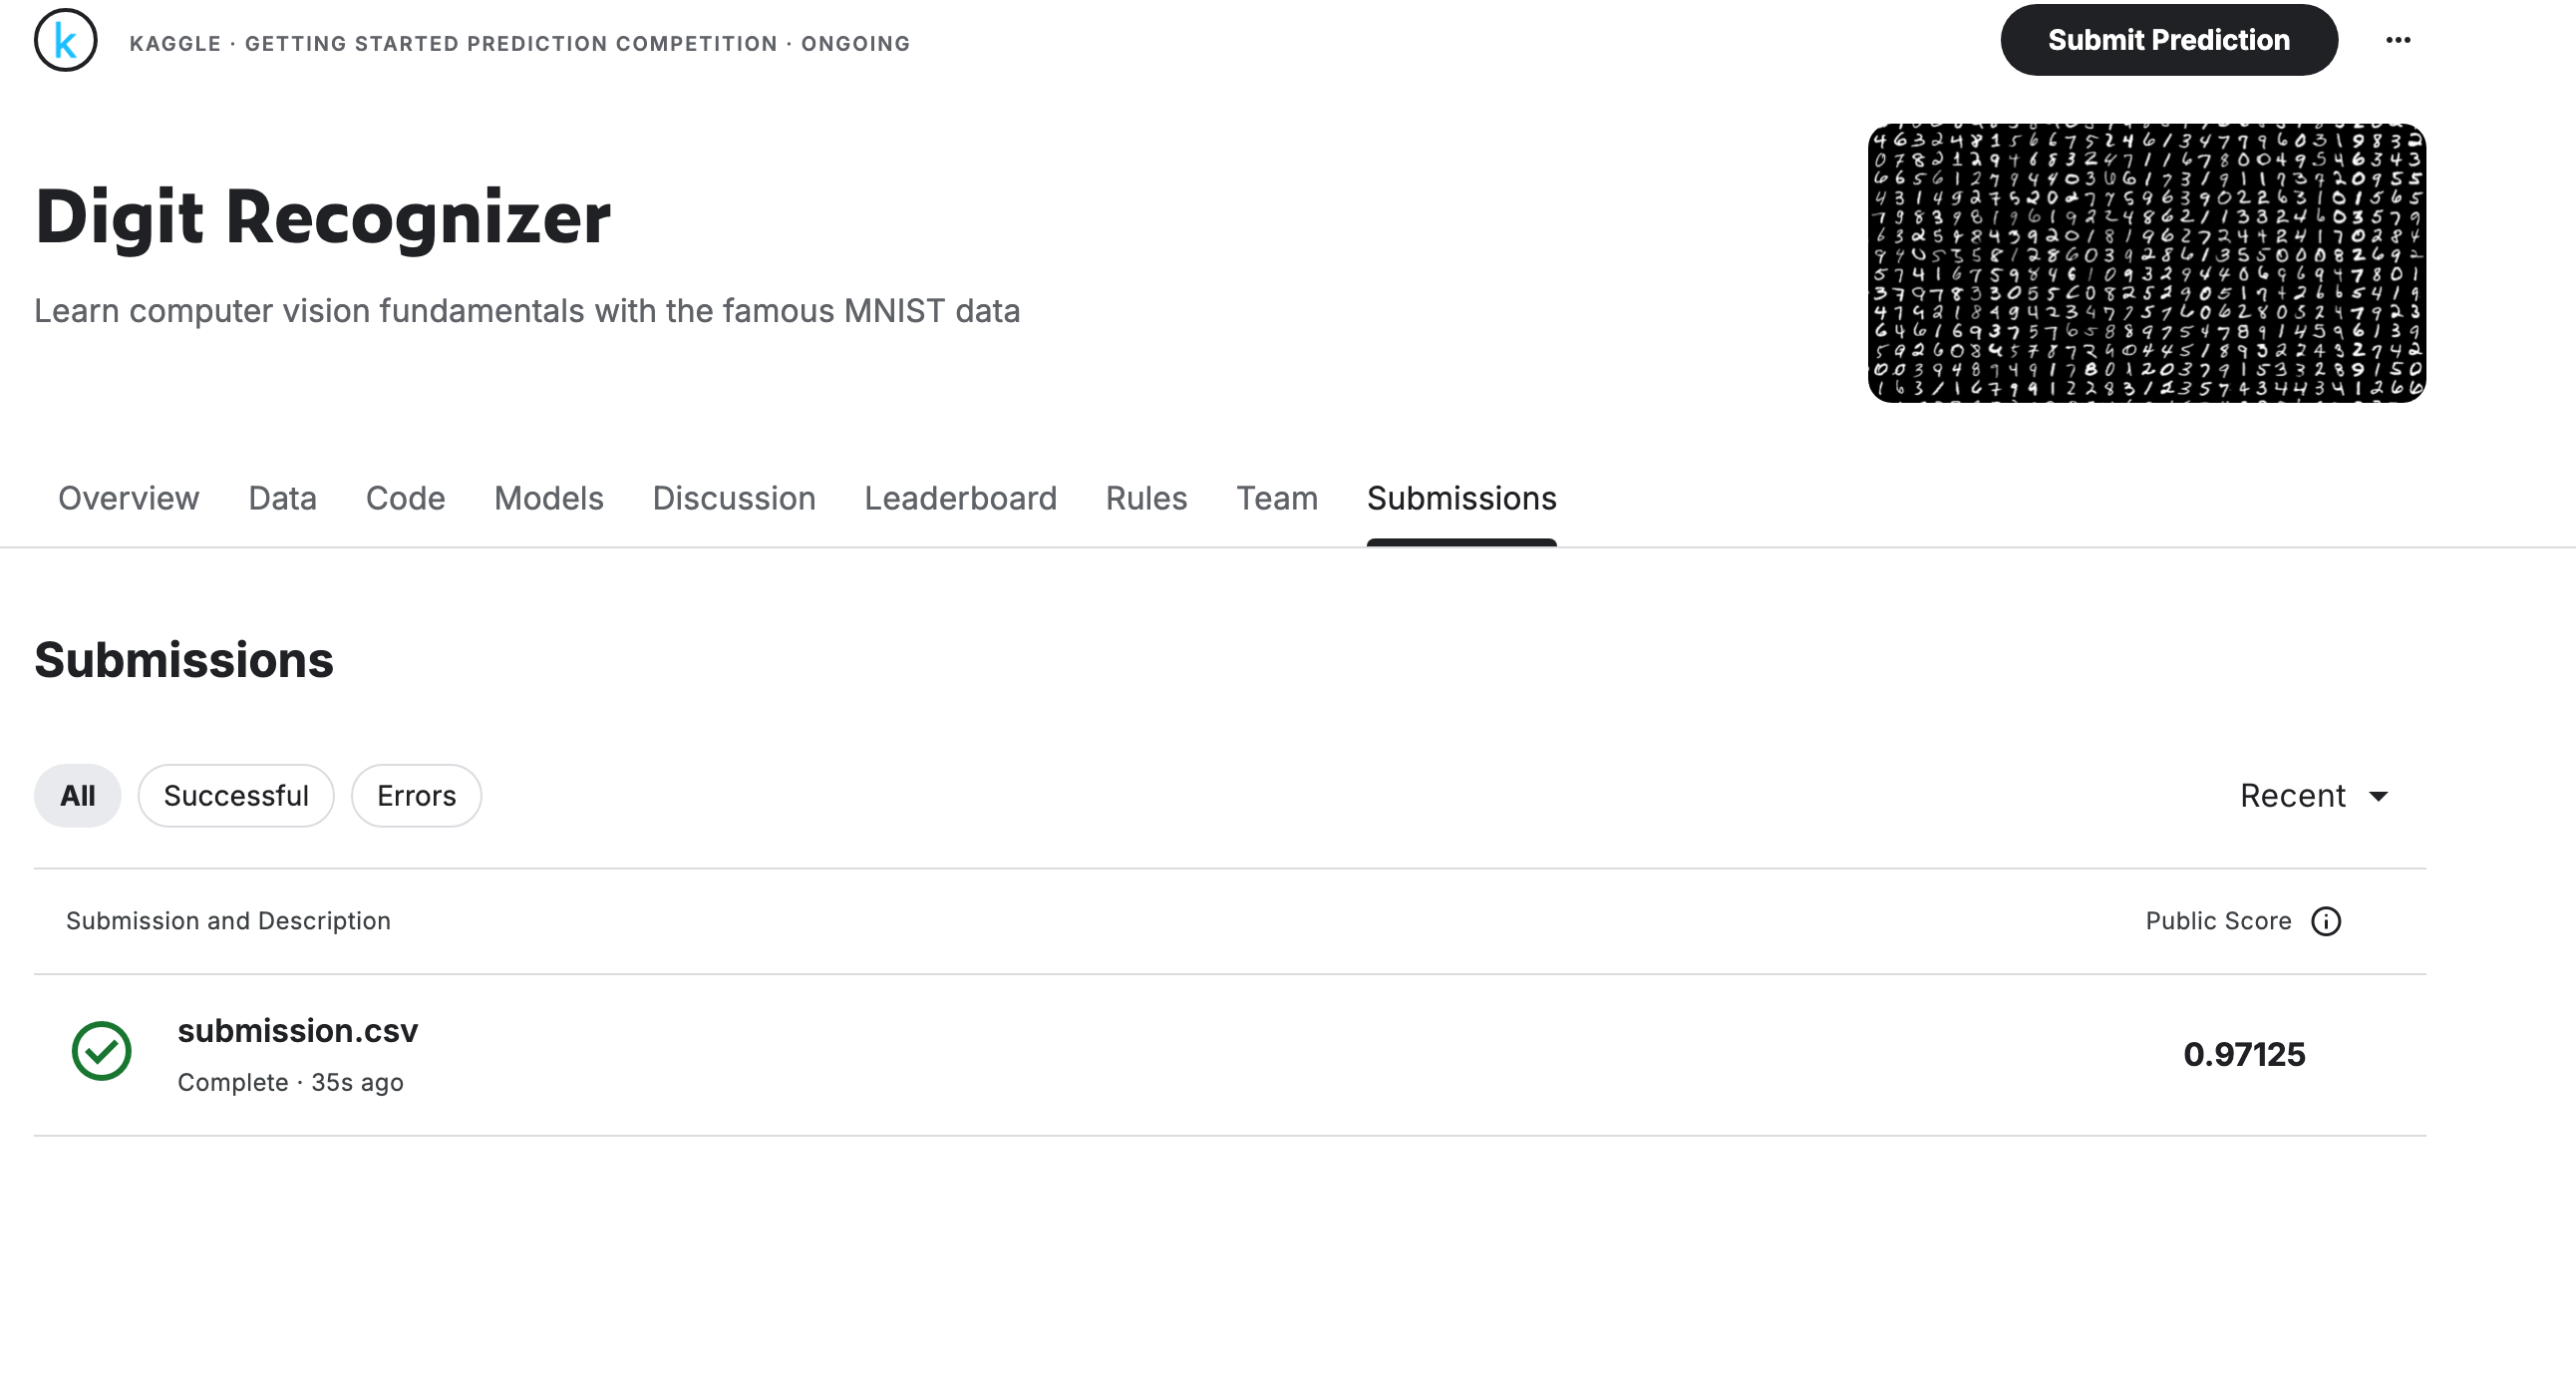